In [1]:
import numpy as np
import random
import matplotlib.pyplot as plt

In [2]:
N = 100          # número de estampas del álbum
S = 7            # estampas por sobre
PRECIO = 9.50    # precio por sobre
PRESUPUESTO = 1000
R = 10000        # simulaciones

SEMILLA = 2026

random.seed(SEMILLA)
np.random.seed(SEMILLA)

In [3]:
def simular_album():

    coleccion = set()
    repetidas = 0

    gasto = 0
    sobres = 0

    while (gasto + PRECIO <= PRESUPUESTO) and (len(coleccion) < N):

        sobres += 1
        gasto += PRECIO

        # generar un sobre
        estampas = np.random.randint(1, N + 1, S)

        for e in estampas:
            if e in coleccion:
                repetidas += 1
            else:
                coleccion.add(e)

    completo = 1 if len(coleccion) == N else 0

    return completo, sobres, len(coleccion)

In [4]:
resultados = [simular_album() for _ in range(R)]

completos = np.array([x[0] for x in resultados])
sobres_comprados = np.array([x[1] for x in resultados])
distintas_obtenidas = np.array([x[2] for x in resultados])

In [5]:

probabilidad_completar = np.mean(completos)

esperado_sobres = np.mean(sobres_comprados)

# solo casos donde NO completó
no_exitosos = distintas_obtenidas[completos == 0]

esperado_distintas = np.mean(no_exitosos)

print("======================================")
print("RESULTADOS - SOBRES SUELTOS")
print("======================================")

print(f"Probabilidad de completar el álbum: {probabilidad_completar:.4f}")

print(f"Número esperado de sobres comprados: {esperado_sobres:.2f}")

print(f"Número esperado de estampas distintas (casos no exitosos): {esperado_distintas:.2f}")

RESULTADOS - SOBRES SUELTOS
Probabilidad de completar el álbum: 0.9447
Número esperado de sobres comprados: 73.48
Número esperado de estampas distintas (casos no exitosos): 98.97


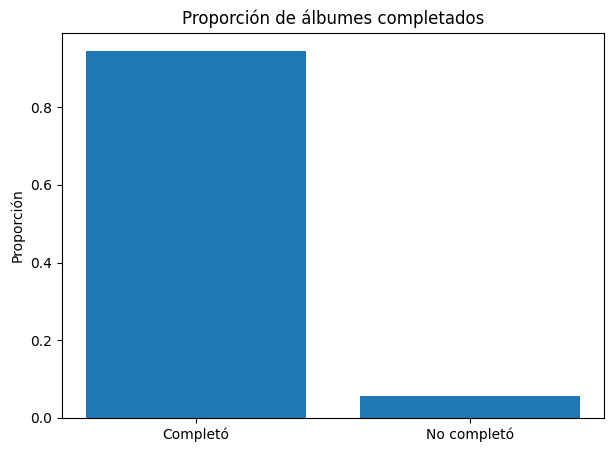


PREGUNTA 1
Máximo número de sobres con Q1000: 105
Máximo teórico de estampas sin repetidas: 735
Mínimo teórico de sobres para completar el álbum sin repetidas: 15
Sí es suficiente en teoría para completar el álbum.

ANÁLISIS:
- Con Q1000 se pueden comprar 105 sobres.
- Cada sobre trae 7 estampas.
- En teoría podrían obtenerse 735 estampas si no hubiera repetidas.
- El mínimo teórico para completar el álbum es 15 sobres.
- En la práctica aparecen muchas repetidas, por eso la probabilidad de completar el álbum no es 100%.



In [6]:
etiquetas = ["Completó", "No completó"]
valores = [
    np.mean(completos),
    1 - np.mean(completos)
]

plt.figure(figsize=(7,5))
plt.bar(etiquetas, valores)

plt.ylabel("Proporción")
plt.title("Proporción de álbumes completados")

plt.show()

print("\n======================================")
print("PREGUNTA 1")
print("======================================")

max_sobres = int(PRESUPUESTO // PRECIO)

print(f"Máximo número de sobres con Q1000: {max_sobres}")

max_estampas_teoricas = max_sobres * S

print(f"Máximo teórico de estampas sin repetidas: {max_estampas_teoricas}")

min_sobres_teoricos = int(np.ceil(N / S))

print(f"Mínimo teórico de sobres para completar el álbum sin repetidas: {min_sobres_teoricos}")

if max_estampas_teoricas >= N:
    print("Sí es suficiente en teoría para completar el álbum.")
else:
    print("No es suficiente en teoría.")

print("""
ANÁLISIS:
- Con Q1000 se pueden comprar 105 sobres.
- Cada sobre trae 7 estampas.
- En teoría podrían obtenerse 735 estampas si no hubiera repetidas.
- El mínimo teórico para completar el álbum es 15 sobres.
- En la práctica aparecen muchas repetidas, por eso la probabilidad de completar el álbum no es 100%.
""")


In [7]:
CAJA_SOBRES = 104

def simular_caja():

    coleccion = set()

    for _ in range(CAJA_SOBRES):

        estampas = np.random.randint(1, N + 1, S)

        for e in estampas:
            coleccion.add(e)

    return 1 if len(coleccion) == N else 0

resultados_caja = np.array([simular_caja() for _ in range(R)])

probabilidad_caja = np.mean(resultados_caja)

print("\n======================================")
print("PREGUNTA 2")
print("======================================")

print(f"Probabilidad de completar el álbum con caja: {probabilidad_caja:.4f}")

print(f"Probabilidad con sobres sueltos: {probabilidad_completar:.4f}")

if probabilidad_caja > probabilidad_completar:
    print("Conviene más la caja.")
elif probabilidad_caja < probabilidad_completar:
    print("Conviene más comprar sobres sueltos.")
else:
    print("Ambas opciones son equivalentes.")

print("""
ANÁLISIS:
- La caja contiene 104 sobres fijos.
- Comprar sobres sueltos permite adquirir hasta 105 sobres.
- La diferencia es pequeña porque solamente cambia un sobre.
- La mejor opción depende de la probabilidad observada en la simulación.
""")



PREGUNTA 2
Probabilidad de completar el álbum con caja: 0.9355
Probabilidad con sobres sueltos: 0.9447
Conviene más comprar sobres sueltos.

ANÁLISIS:
- La caja contiene 104 sobres fijos.
- Comprar sobres sueltos permite adquirir hasta 105 sobres.
- La diferencia es pequeña porque solamente cambia un sobre.
- La mejor opción depende de la probabilidad observada en la simulación.



In [8]:
print("\n======================================")
print("PREGUNTA 3")
print("======================================")

costo_caja = 975

dinero_restante = PRESUPUESTO - costo_caja

sobres_extra = int(dinero_restante // PRECIO)

print(f"Dinero restante después de comprar la caja: Q{dinero_restante:.2f}")

print(f"Sobres adicionales posibles: {sobres_extra}")

print("""
ANÁLISIS:
- Comprar la caja deja dinero sin utilizar.
- Con el dinero restante se pueden comprar algunos sobres adicionales.
- Una estrategia mixta puede aumentar la probabilidad de completar el álbum.
- La estrategia recomendada es:
    1. Comprar la caja de 104 sobres.
    2. Usar el dinero restante para comprar sobres adicionales.
- Esto maximiza el uso del presupuesto sin exceder Q1000.
""")


PREGUNTA 3
Dinero restante después de comprar la caja: Q25.00
Sobres adicionales posibles: 2

ANÁLISIS:
- Comprar la caja deja dinero sin utilizar.
- Con el dinero restante se pueden comprar algunos sobres adicionales.
- Una estrategia mixta puede aumentar la probabilidad de completar el álbum.
- La estrategia recomendada es:
    1. Comprar la caja de 104 sobres.
    2. Usar el dinero restante para comprar sobres adicionales.
- Esto maximiza el uso del presupuesto sin exceder Q1000.



In [9]:

def simular_mixto():

    coleccion = set()

    total_sobres = CAJA_SOBRES + sobres_extra

    for _ in range(total_sobres):

        estampas = np.random.randint(1, N + 1, S)

        for e in estampas:
            coleccion.add(e)

    return 1 if len(coleccion) == N else 0

resultado_mixto = np.array([simular_mixto() for _ in range(R)])

probabilidad_mixto = np.mean(resultado_mixto)

print("======================================")
print("ESTRATEGIA MIXTA")
print("======================================")

print(f"Probabilidad de completar con estrategia mixta: {probabilidad_mixto:.4f}")

print("""
CONCLUSIÓN FINAL:
- Sobres sueltos: permite flexibilidad.
- Caja: puede ser conveniente por el costo fijo.
- Estrategia mixta: suele ser la mejor porque aprovecha todo el presupuesto.
""")

ESTRATEGIA MIXTA
Probabilidad de completar con estrategia mixta: 0.9459

CONCLUSIÓN FINAL:
- Sobres sueltos: permite flexibilidad.
- Caja: puede ser conveniente por el costo fijo.
- Estrategia mixta: suele ser la mejor porque aprovecha todo el presupuesto.

